# KFold Experiments

In [18]:
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'

In [ ]:
from diquark.data.loader import DataLoader

path_dict = {
    "BKG:qcd": "/data/gmajeri/madgraph-script-generator/diquark-repro/data/background/qcd_multijet/Events/run_01/tag_1_delphes_events.root",
    "BKG:ttbar": "/data/gmajeri/madgraph-script-generator/diquark-repro/data/background/ttbar_plus_jets/Events/run_01/tag_1_delphes_events.root",
    "SIG:New": "/data/gmajeri/madgraph-script-generator/diquark-repro/data/signal/Suu_chichi_WbWb_MSuu_8TeV_higher_xqcut/Events/run_01/tag_1_delphes_events.root",
}

data_loader = DataLoader(
    path_dict,
    # index_start=0,
    # index_stop=50_000,
)

In [2]:
data = data_loader.load_data()
data

Loading data:   0%|          | 0/3 [00:00<?, ?it/s]

{'BKG:qcd': <Array [{Jet: 4, 'Jet/Jet.PT': ..., ...}, ...] type='44269 * {Jet: int32, "...'>,
 'BKG:ttbar': <Array [{Jet: 13, 'Jet/Jet.PT': ..., ...}, ...] type='49414 * {Jet: int32, ...'>,
 'SIG:New': <Array [{Jet: 6, 'Jet/Jet.PT': ..., ...}, ...] type='49978 * {Jet: int32, "...'>}

In [3]:
from diquark.features.feature_extractor import FeatureExtractor

feature_extractor = FeatureExtractor(
    n_jets=32,
    chi_mass=8000,
    suu_mass=2000,
)

In [ ]:
features = {
    key: feature_extractor.compute_all(dataset) for key, dataset in data.items()
}

In [5]:
from diquark.data.preprocessor import Preprocessor

preprocessor = Preprocessor({})

In [6]:
df = preprocessor.create_dataframe(features)
df

,jet_multiplicity,p_T_sum,p_T_min,p_T_mean,p_T_stddev,p_T_max,eta_sum,eta_min,eta_mean,eta_stddev,...,chi2_second_component_mean,chi2_second_component_stddev,chi2_second_component_max,chi2_third_component_sum,chi2_third_component_min,chi2_third_component_mean,chi2_third_component_stddev,chi2_third_component_max,Truth,target
0,4,262.089386,24.205441,65.522346,40.367149,118.345909,0.452723,-2.478559,0.113181,2.496126,...,1595.115845,592.049147,2352.428467,0.000000,0.000000,0.000000,0.000000,0.000000,BKG:qcd,0
1,6,1061.898438,71.977280,176.983073,78.977431,299.389954,-1.808857,-3.143430,-0.301476,2.508684,...,1130.248535,535.859075,2277.105957,2346.730957,2346.730957,2346.730957,NaN,2346.730957,BKG:qcd,0
2,8,615.061096,26.376211,76.882637,55.284488,187.878235,-3.820896,-3.755611,-0.477612,2.818780,...,1573.665876,703.847180,2429.266602,50189.390625,0.015663,1792.478237,1436.521016,3589.484131,BKG:qcd,0
3,5,1064.545166,46.802998,212.909033,185.478890,479.962952,4.708995,-2.545586,0.941799,2.569930,...,998.957129,736.819146,2100.395752,0.000000,0.000000,0.000000,0.000000,0.000000,BKG:qcd,0
4,2,239.177185,109.773445,119.588593,9.815196,129.403748,-0.523050,-4.376416,-0.261525,4.114891,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,BKG:qcd,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143656,5,5315.002930,118.209229,1063.000586,999.143811,2514.162842,-1.403828,-1.170392,-0.280766,0.759720,...,1023.354883,538.768488,2039.159668,0.000000,0.000000,0.000000,0.000000,0.000000,SIG:New,1
143657,9,5352.291016,46.565258,594.699002,705.231788,2095.829102,1.877829,-1.566295,0.208648,1.206231,...,1564.768973,581.134493,2309.236084,96422.218750,0.511323,1147.883557,1060.553273,3213.408691,SIG:New,1
143658,7,6534.132324,26.389366,933.447475,1043.461662,2835.477783,3.181056,-0.284969,0.454437,0.572262,...,1493.463616,740.480017,2405.311523,13686.795898,47.855930,1955.256557,1102.581554,2970.249512,SIG:New,1
143659,8,6527.452637,29.917173,815.931580,662.966935,1689.850220,3.075750,-1.072082,0.384469,0.839973,...,1253.405692,669.699527,2433.038574,70565.515625,436.399017,2520.196987,1506.919566,5443.615234,SIG:New,1


In [7]:
X = df.drop(["target", "Truth"], axis=1)
y = df["target"]

In [ ]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# skf.split(X, y)

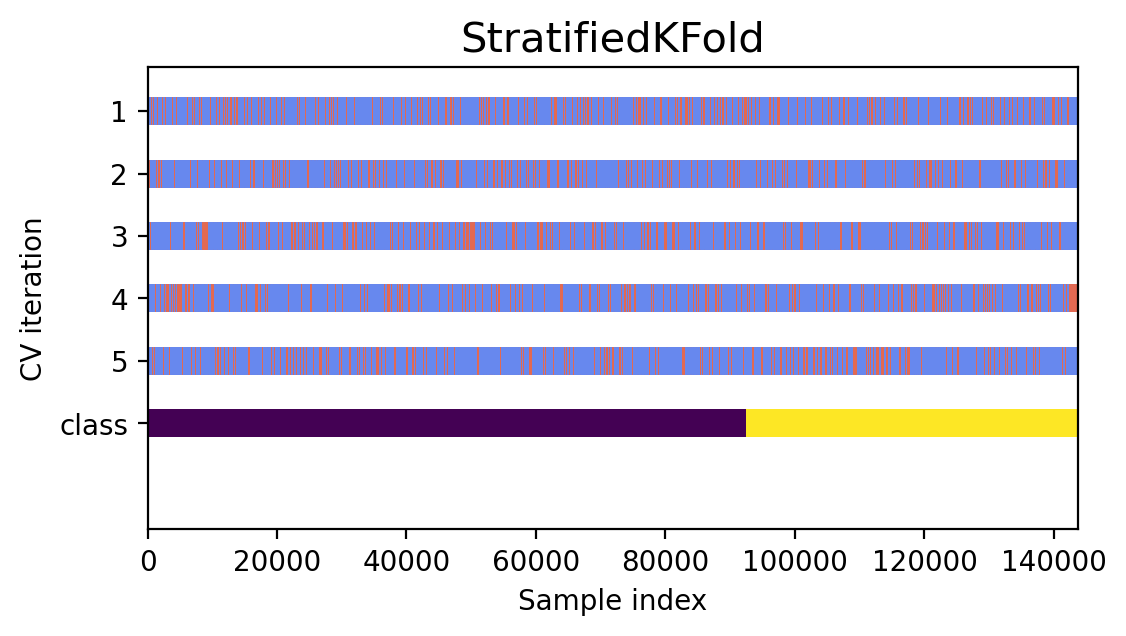

In [29]:
def plot_cv_indices(cv, X, y, ax, n_splits, lw=10):
    """Create a sample plot for indices of a cross-validation object."""
    # Generate the training/testing visualizations for each CV split
    for ii, (tr, tt) in enumerate(cv.split(X=X, y=y)):
        # Fill in indices with the training/test groups
        indices = np.array([np.nan] * len(X))
        indices[tt] = 1
        indices[tr] = 0

        # Visualize the results
        ax.scatter(
            range(len(indices)),
            [ii + 0.5] * len(indices),
            c=indices,
            marker="_",
            lw=lw,
            cmap="coolwarm",
            vmin=-0.2,
            vmax=1.2,
        )

    # Plot the data classes and groups at the end
    ax.scatter(
        range(len(X)), [ii + 1.5] * len(X), c=y, marker="_", lw=lw
    )

    # Formatting
    yticklabels = list(range(1, n_splits + 1)) + ["class"]
    ax.set(
        yticks=np.arange(n_splits + 1) + 0.5,
        yticklabels=yticklabels,
        xlabel="Sample index",
        ylabel="CV iteration",
        ylim=[n_splits + 2.2, -0.2],
        xlim=[0, len(X)],
    )
    ax.set_title("{}".format(type(cv).__name__), fontsize=15)
    return ax

fig, ax = plt.subplots(figsize=(6, 3))
plot_cv_indices(skf, X, y, ax, n_splits=5)
plt.show()

In [ ]:
for ii, (tr, tt) in enumerate(skf.split(X=X, y=y)):

    print(df['Truth'].iloc[tr].value_counts())


Truth
SIG:New      39982
BKG:ttbar    39393
BKG:qcd      35553
Name: count, dtype: int64
Truth
SIG:New      39983
BKG:ttbar    39614
BKG:qcd      35332
Name: count, dtype: int64
Truth
SIG:New      39983
BKG:ttbar    39585
BKG:qcd      35361
Name: count, dtype: int64
Truth
SIG:New      39982
BKG:ttbar    39619
BKG:qcd      35328
Name: count, dtype: int64
Truth
SIG:New      39982
BKG:ttbar    39445
BKG:qcd      35502
Name: count, dtype: int64


ValueError: 'c' argument must be a color, a sequence of colors, or a sequence of numbers, not 0         BKG:qcd
1         BKG:qcd
2         BKG:qcd
3         BKG:qcd
4         BKG:qcd
           ...   
143656    SIG:New
143657    SIG:New
143658    SIG:New
143659    SIG:New
143660    SIG:New
Name: Truth, Length: 143661, dtype: str

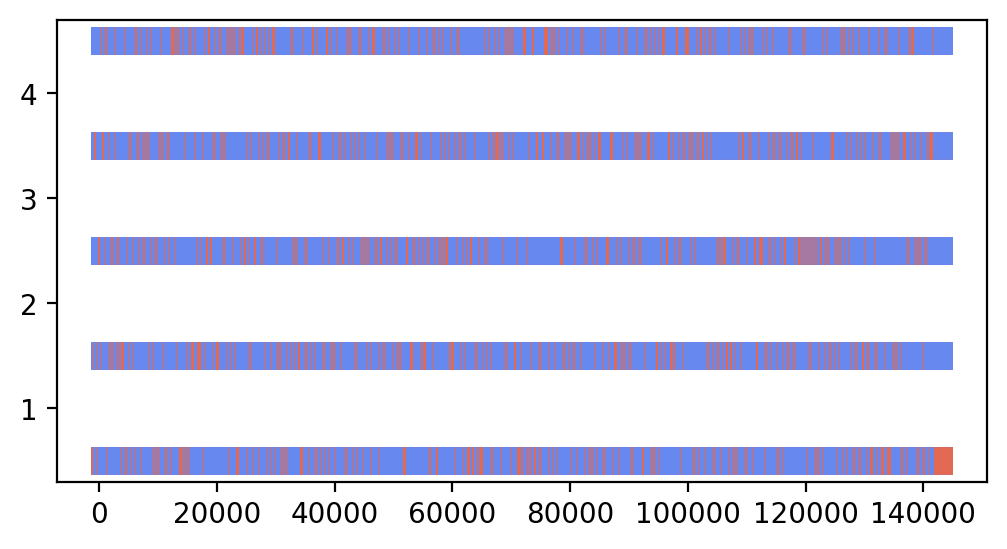

In [30]:

fig, ax = plt.subplots(figsize=(6, 3))
plot_cv_indices(skf, X, df['Truth'], ax, n_splits=5)
plt.show()